In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("data/Forecasting Case- Study.xlsx")

In [3]:

print(df.head())

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by=['State', 'Date'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8084 entries, 0 to 3224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   object        
 1   Date      8084 non-null   datetime64[ns]
 2   Total     8084 non-null   float64       
 3   Category  8084 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 315.8+ KB
None


In [5]:
# -----------------------------
# FEATURE ENGINEERING
# -----------------------------

# Previous sales (1 previous record)
df['lag_1'] = df.groupby('State')['Total'].shift(1)

# Sales from 7 previous records
df['lag_7'] = df.groupby('State')['Total'].shift(7)

# Average sales of previous 7 records
df['rolling_mean_7'] = (
    df.groupby('State')['Total']
    .transform(lambda x: x.rolling(window=7).mean())
)

# Extract month from date
df['month'] = df['Date'].dt.month

# Extract day of week
df['day_of_week'] = df['Date'].dt.dayofweek

# Remove rows with null values
df = df.dropna()

# Display first rows
print(df.head())

# Show all columns
print(df.columns)

        State       Date        Total   Category        lag_1        lag_7  \
7095  Alabama 2019-10-27  109968010.6  Beverages  116218908.9  109574036.0   
4472  Alabama 2019-11-17  109056410.0  Beverages  109968010.6  112189103.8   
6321  Alabama 2019-11-24  113040422.1  Beverages  109056410.0  129106730.4   
3956  Alabama 2019-12-15  108528456.4  Beverages  113040422.1  108083723.8   
5805  Alabama 2019-12-22  116541575.0  Beverages  108528456.4  110932912.8   

      rolling_mean_7  month  day_of_week  
7095    1.157545e+08     10            6  
4472    1.153070e+08     11            6  
6321    1.130118e+08     11            6  
3956    1.130753e+08     12            6  
5805    1.138766e+08     12            6  
Index(['State', 'Date', 'Total', 'Category', 'lag_1', 'lag_7',
       'rolling_mean_7', 'month', 'day_of_week'],
      dtype='object')


In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Features used for prediction
features = [
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'month',
    'day_of_week'
]

# Input features
X = df[features]

# Target column
y = df['Total']

# Time-series split
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Create model
model = XGBRegressor()

# Train model
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 8077452.948490688


Matplotlib is building the font cache; this may take a moment.


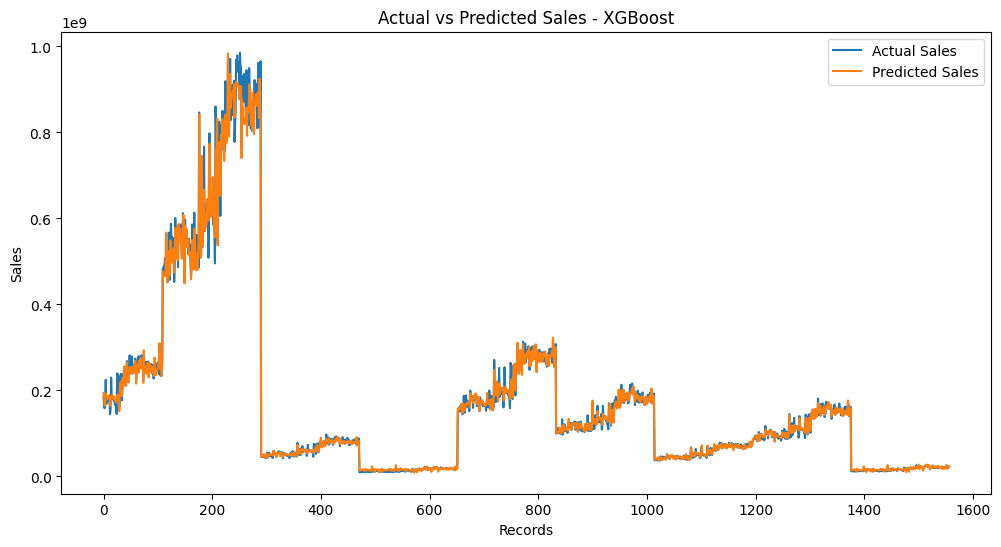

In [7]:
import matplotlib.pyplot as plt

# Plot graph
plt.figure(figsize=(12,6))

# Actual sales
plt.plot(y_test.values, label='Actual Sales')

# Predicted sales
plt.plot(predictions, label='Predicted Sales')

# Titles
plt.title("Actual vs Predicted Sales - XGBoost")

plt.xlabel("Records")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Use only Total sales
sales_data = df['Total']

# Train-test split
train_size = int(len(sales_data) * 0.8)

train = sales_data[:train_size]

test = sales_data[train_size:]

# Create ARIMA model
model = ARIMA(train, order=(1,1,1))

# Train model
model_fit = model.fit()

# Forecast
predictions = model_fit.forecast(steps=len(test))

# Evaluate
mae = mean_absolute_error(test, predictions)

print("ARIMA MAE:", mae)

c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMA MAE: 140203274.97618


c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
# Set Date as index
sales_data = df.set_index('Date')['Total']

# Train-test split
train_size = int(len(sales_data) * 0.8)

train = sales_data[:train_size]

test = sales_data[train_size:]

# ARIMA model
model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

# Forecast
predictions = model_fit.forecast(steps=len(test))

# MAE
mae = mean_absolute_error(test, predictions)

print("ARIMA MAE:", mae)

c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not mo

ARIMA MAE: 140203274.97618


c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Prepare Prophet dataset
prophet_df = df[['Date', 'Total']].copy()

# Rename columns
prophet_df.columns = ['ds', 'y']

# Train-test split
train_size = int(len(prophet_df) * 0.8)

train = prophet_df[:train_size]

test = prophet_df[train_size:]

# Create model
model = Prophet()

# Train
model.fit(train)

# Future dataframe
future = model.make_future_dataframe(periods=len(test))

# Predict
forecast = model.predict(future)

# Extract predictions
predictions = forecast['yhat'][-len(test):].values

# Evaluate
mae = mean_absolute_error(test['y'], predictions)

print("Prophet MAE:", mae)

c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
11:01:44 - cmdstanpy - INFO - Chain [1] start processing
11:01:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 163527716.43377385


In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# Use Total sales
sales_data = df['Total'].values.reshape(-1,1)

# Scale data
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(sales_data)

# Create sequences
X = []
y = []

sequence_length = 7

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

# Train-test split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Build LSTM model
model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))

model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predict
predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

# Evaluate
mae = mean_absolute_error(y_test_actual, predictions)

print("LSTM MAE:", mae)

Epoch 1/10


c:\Users\91900\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0032
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011   
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0010    
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0010    
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.9020e-04
Epoch 9/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.7409e-04
Epoch 10/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.6041e-04
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM MAE: 15043814.859125964


In [12]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['XGBoost', 'ARIMA', 'Prophet', 'LSTM'],
    'MAE': [
        8077452.94,
        140203274.97,
        163527716.43,
        15043814.85
    ]
})

print(results)

     Model           MAE
0  XGBoost  8.077453e+06
1    ARIMA  1.402033e+08
2  Prophet  1.635277e+08
3     LSTM  1.504381e+07


In [13]:
best_model = results.loc[results['MAE'].idxmin()]

print("Best Model:")
print(best_model)

Best Model:
Model       XGBoost
MAE      8077452.94
Name: 0, dtype: object


In [14]:
import joblib

# Save XGBoost model
joblib.dump(model, 'best_xgboost_model.pkl')

print("Model saved successfully")

Model saved successfully


In [15]:
from xgboost import XGBRegressor

# Features
features = [
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'month',
    'day_of_week'
]

X = df[features]
y = df['Total']

train_size = int(len(df) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

# Train best model again
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

print("XGBoost model retrained")

XGBoost model retrained


In [16]:
import joblib

joblib.dump(xgb_model, 'best_xgboost_model.pkl')

print("Best model saved successfully")

Best model saved successfully
